<a href="https://colab.research.google.com/github/yastreb13/dzdlmfti/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22AI_Edu_Modern_CV_Homework_1%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Education. Современное компьютерное зрение
# Домашнее задание 1

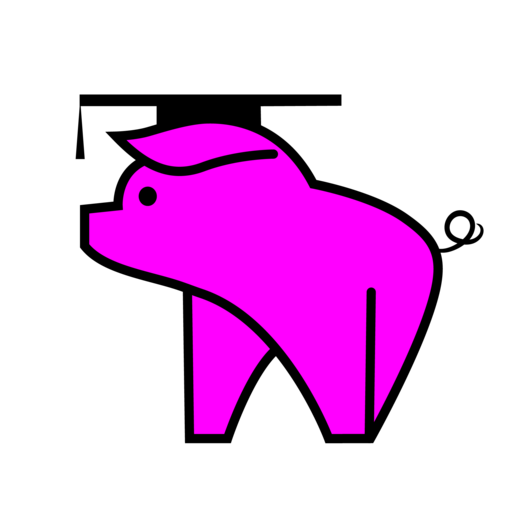

Используя код с занятия и архитектуру на картинке, напишите класс модели VGG16 и запустите обучение на небольшом кусочке ImageNet. Самостоятельно подберите параметры обучения, чтобы получить приемлемый результат. Используйте ресурсы GoogleColab или Kaggle, если не имеете локального GPU или что-то не влезает в память.

Датасет будем качать отсюда https://www.kaggle.com/datasets/akash2sharma/tiny-imagenet/data

Внимание! Датасет при своем небольшом весе будет долго распаковываться, так как в нем очень много маленьких изображений.

Текст статьи, где можно найти подробную архитектуру https://arxiv.org/pdf/1409.1556v6

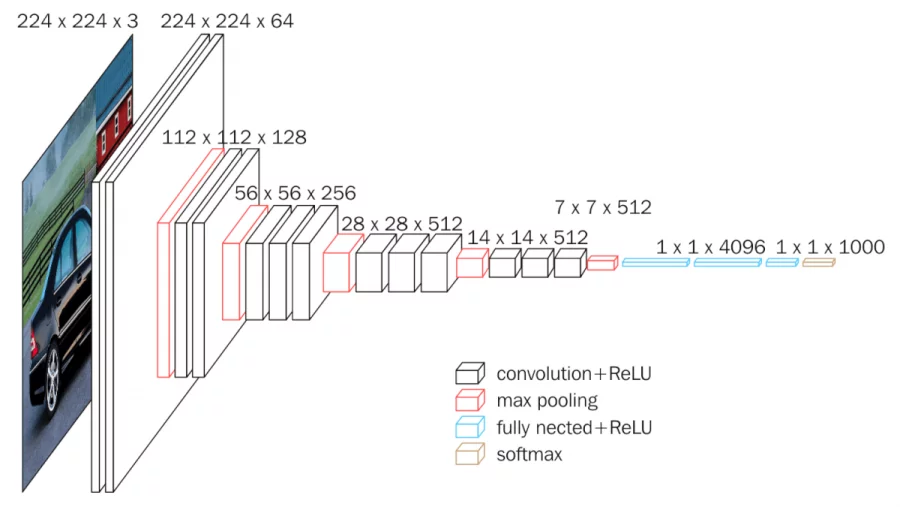

### Архитектура модели (4 балла)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image
import pandas as pd

# Определение модели VGG-16
class VGG16(nn.Module):
    def __init__(self, num_classes=1000):
        super(VGG16, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),)
        self.classifier = nn.Sequential(
            nn.Linear(512 * 2 * 2, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, num_classes),
        )
    def forward(self, x):
        x=self.layers(x)
        x=torch.flatten(x,1)
        x=self.classifier(x)
        return x

### Класс датасета (0 баллов)

In [2]:
class TinyImageNetDataset(Dataset):
    def __init__(self, root_dir, transform=None, train=True):
        self.root_dir = root_dir

        self.train = train
        self.transform = transform

        if self.train:
            self.data = []
            self.labels = []
            classes = sorted(os.listdir(os.path.join(root_dir, 'train')))

            # Поиск картинок и присвоение labels
            for label, cls in enumerate(classes):
                cls_dir = os.path.join(root_dir, 'train', cls, 'images')
                for img_name in os.listdir(cls_dir):
                    self.data.append(os.path.join(cls_dir, img_name)) # store the path only
                    self.labels.append(label)
        else:
            self.data = []
            self.labels = []
            val_dir = os.path.join(root_dir, 'val', 'images')

            # Чтение csv файлов с данными
            val_annotations = pd.read_csv(os.path.join(root_dir, 'val', 'val_annotations.txt'),
                                          sep='\t', header=None,
                                          names=['file_name', 'class', 'x1', 'y1', 'x2', 'y2'])
            class_to_idx = {cls: idx for idx, cls in enumerate(sorted(os.listdir(os.path.join(root_dir, 'train'))))}
            for _, row in val_annotations.iterrows():
                self.data.append(os.path.join(val_dir, row['file_name']))
                self.labels.append(class_to_idx[row['class']])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        # Если кастомные трансформации переданы, применяем их
        if self.transform:
            image = self.transform(image)
        else:
            # Если трансформаций нет, ОБЯЗАТЕЛЬНО переводим в тензор руками
            image = transforms.ToTensor()(image)

        return image, label

### Трансформации, оптимизатор, лосс и прочее (0 баллов)

In [3]:
# Настройки
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 32
num_epochs = 10
learning_rate = 0.001

# Пример преобразований для данных
train_transforms = transforms.Compose([
    transforms.RandomCrop(64, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [4]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"whoisiticanttakeit","key":"80d3f67f380625412a79041f6ccfc023"}'}

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("akash2sharma/tiny-imagenet")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tiny-imagenet' dataset.
Path to dataset files: /kaggle/input/tiny-imagenet


In [6]:
import os
print(os.listdir(r'/root/.cache/kagglehub/datasets/akash2sharma/tiny-imagenet/versions/1'))

FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/akash2sharma/tiny-imagenet/versions/1'

In [7]:
data_dir =r'/kaggle/input/tiny-imagenet/tiny-imagenet-200'
train_dataset = TinyImageNetDataset(root_dir=data_dir, train=True)
val_dataset = TinyImageNetDataset(root_dir=data_dir, train=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


### Цикл обучения (6 баллов + бонус)

Напишите цикл обучения и проверьте, чтобы он работал. (3 балла)

Обучите модель, достигните val_accuracy > 0.3 (3 балла). В попытках улучшить модель, можете добавить аугментаций, поменять оптимизаторы, добавить в архитектуру батчнормы, дропауты и т.д.

Попробуйте улучшить исходную заготовку для кода: оберните цикл обучения в функцию (1 балл), добавьте отрисовку графика обучения в реальном времени (2 балла), создайте отдельную функцию для валидации и вызывайте ее не каждую эпоху (2 балла). Можете придумать свои улучшения, мы их тоже обязательно оценим (не более 5 баллов за всё).

In [8]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

def validate(model, val_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    return val_acc

def train(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device):
    train_losses = []
    val_accs = [0]
    val_epochs = [0]
    epoch = 0
    while max(val_accs)<30.1:
        model.train()
        running_loss = 0.0
        i = 0

        for inputs, labels in train_loader:
            if i % 500 == 0:
                print(i)
            i += 1

            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)

        if (epoch + 1) % 2 == 0:
            val_acc = validate(model, val_loader, device)
            val_accs.append(val_acc)
            val_epochs.append(epoch + 1)

            scheduler.step(val_acc)

        clear_output(wait=True)
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.plot(range(1, epoch + 2), train_losses)
        plt.title('Train Loss')

        plt.subplot(1, 2, 2)
        if len(val_accs) > 0:
            plt.plot(val_epochs, val_accs, color='green', marker='o')
        plt.title('Validation Accuracy')

        plt.show()

        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}')
        if (epoch + 1) % 2 == 0:
            print(f'Validation Accuracy: {val_acc:.2f}%')
        epoch+=1

    return model

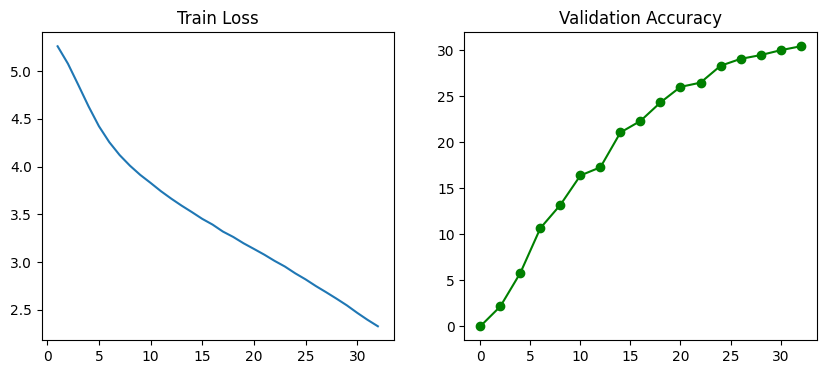

Epoch 32/10, Train Loss: 2.3274
Validation Accuracy: 30.41%


In [9]:
import torch.optim as optim
import torch.nn as nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = VGG16(num_classes=200).to(device)
criterion = nn.CrossEntropyLoss()
num_epochs = 10
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=2)
print("Начинаем обучение")
model = train(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device)

In [10]:
torch.save(model.state_dict(), 'best_model.pth')

### Бонус (3 балла)
Ниже написан код модели ResNet-50. Попробуйте проверить гипотезу о том, что градиенты без пробросов будут затухать. Сделайте это, отследив в цикле обучения на ImageNet распределение модулей градентов весов и сравните это же распределение на модели ResNet-50 без пробросов (чтобы их убрать, нужно модифицировать forward модели).

Подсказка: градиенты тензора можно получить, например, написав tensor.grad

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, channels, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)

        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

        self.conv3 = nn.Conv2d(channels, channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1000):
        super(ResNet, self).__init__()
        self.in_channels = 64

        # Начальные слои
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Ботлнеки
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        # Классификаторный слой
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        # Инициализация весов
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, channels * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(channels * block.expansion),
            )

        layers = []
        layers.append(block(self.in_channels, channels, stride, downsample))
        self.in_channels = channels * block.expansion

        for _ in range(1, blocks):
            layers.append(block(self.in_channels, channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

def resnet50(num_classes=1000):
    return ResNet(Bottleneck, [3, 4, 6, 3], num_classes=num_classes)

In [12]:

class Bottleneckwores(nn.Module):
    expansion = 4

    def __init__(self, in_channels, channels, stride=1, downsample=None):
        super(Bottleneckwores, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)

        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

        self.conv3 = nn.Conv2d(channels, channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)
        out = self.relu(out)

        return out

def resnet50wores(num_classes=1000):
    return ResNet(Bottleneckwores, [3, 4, 6, 3], num_classes=num_classes)

In [13]:
modelwres = resnet50()
modelwores = resnet50wores()
input_tensor = torch.randn(1, 3, 224, 224)
outputwres = modelwres(input_tensor)
print(f"Output shape: {outputwres.shape}")
outputwores = modelwores(input_tensor)
print(f"Output shape: {outputwores.shape}")

criterion(modelwres(input_tensor), torch.tensor([1])).backward()
print(modelwres.conv1.weight.grad.abs().mean())
criterion(modelwores(input_tensor), torch.tensor([1])).backward()
print(modelwores.conv1.weight.grad.abs().mean())


Output shape: torch.Size([1, 1000])
Output shape: torch.Size([1, 1000])
tensor(3.7543)
tensor(99.9545)
